In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os
from IPython.display import display
import scipy.stats as stats
from scipy.stats import linregress

In [2]:
stocks_info = {
    'NVDA': {'color': 'navy', 'file': 'data/NVIDIA Stock Price History.csv'},
    'AMD': {'color': 'orange', 'file': 'data/AMD Stock Price History.csv'},
    'AVGO': {'color': 'green', 'file': 'data/Broadcom Stock Price History.csv'},
    'INTC': {'color': 'skyblue', 'file': 'data/Intel Stock Price History.csv'},
}

NVDA - Loading data from data/NVIDIA Stock Price History.csv
AMD - Loading data from data/AMD Stock Price History.csv
AVGO - Loading data from data/Broadcom Stock Price History.csv
INTC - Loading data from data/Intel Stock Price History.csv


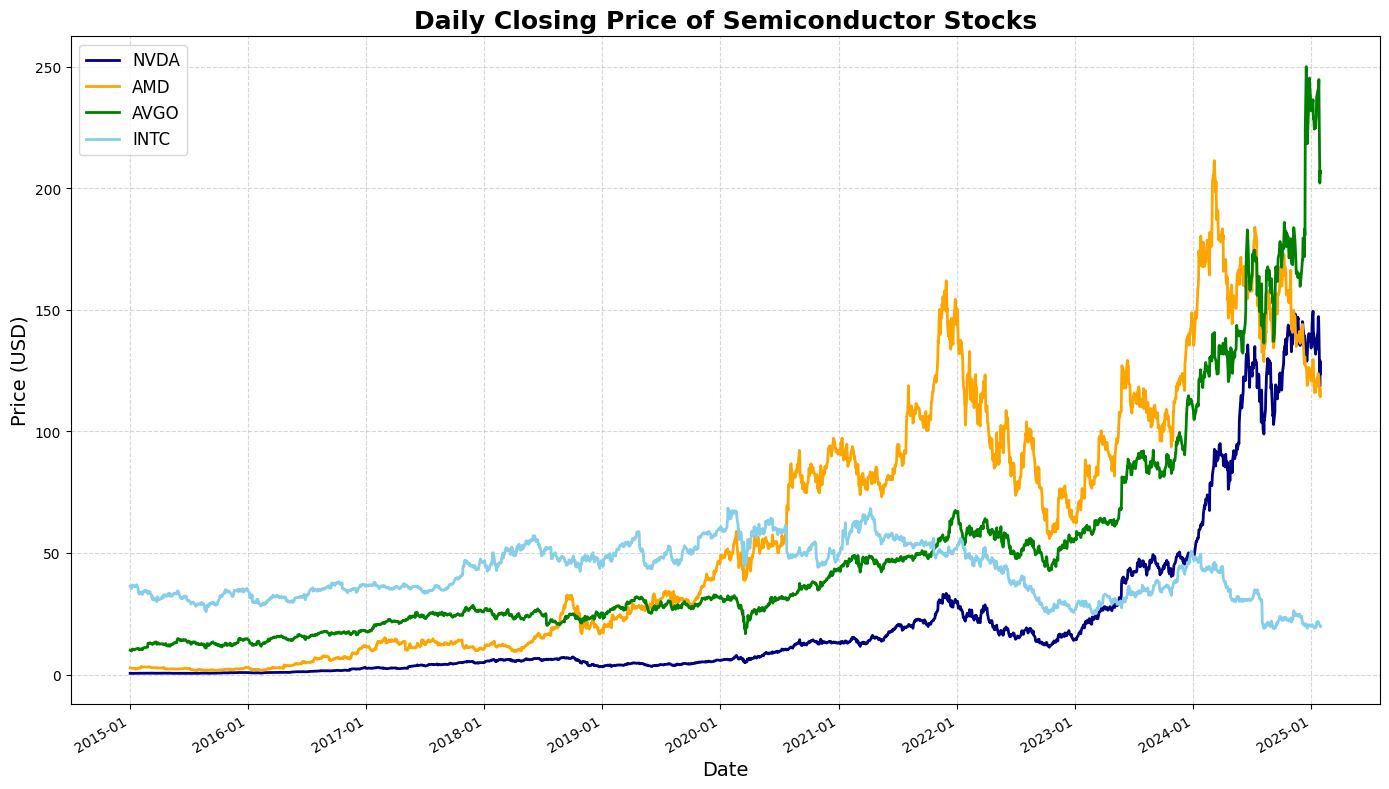

In [3]:
plt.figure(figsize=(14, 8))

for symbol, info in stocks_info.items():
    file_path = info['file']
    color = info['color']

    if not os.path.exists(file_path):
        print(f"File Error: {file_path} does not exists.")
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    df = df[df['Date'] != pd.to_datetime('2016-02-27')]

    df = df.sort_values('Date')

    df['Return'] = df['Price'].pct_change()

    if df['Price'].dtype == 'object':
        df['Price'] = df['Price'].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    plt.plot(df['Date'], df['Price'], label = symbol, color = color, linewidth = 2)

plt.title('Daily Closing Price of Semiconductor Stocks', fontsize = 18, fontweight = 'bold')
plt.xlabel('Date', fontsize = 14)
plt.ylabel('Price (USD)', fontsize = 14)
plt.legend(loc = 'upper left', fontsize = 12, frameon = True)
plt.grid(True, linestyle = '--', alpha = 0.5)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [4]:
assets_info = {
    'DJI': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            },
    'DJI_mod': {'color': 'navy', 'file': 'data/Dow Jones Industrial Average Historical Data.csv', 'label': 'Index Value',
            'ylim': (0, 15000), 'ystep': 2500},
    'XAU': {'color': 'navy', 'file': 'data/XAU_USD Historical Data.csv', 'label': 'Price (USD per ounce)',
            'ylim': (0, 3000), 'ystep': 500},
    'EUR': {'color': 'navy', 'file': 'data/EUR_USD Historical Data.csv', 'label': 'Price (USD per EUR)',
            'ylim': (0.8, 1.4), 'ystep': 0.1},
    'WTI': {'color': 'navy', 'file': 'data/WTI_USD Historical Data.csv', 'label': 'Price (USD/bbl)',
            'ylim': (0, 140), 'ystep': 20},
    'BTC': {'color': 'navy', 'file': 'data/Bitcoin Historical Data.csv', 'label': 'Price (USD/BTC)',
            'ylim': (0, 120000), 'ystep': 20000},
}

DJI - Loading data from data/Dow Jones Industrial Average Historical Data.csv
DJI_mod - Loading data from data/Dow Jones Industrial Average Historical Data.csv
XAU - Loading data from data/XAU_USD Historical Data.csv
EUR - Loading data from data/EUR_USD Historical Data.csv
WTI - Loading data from data/WTI_USD Historical Data.csv
BTC - Loading data from data/Bitcoin Historical Data.csv


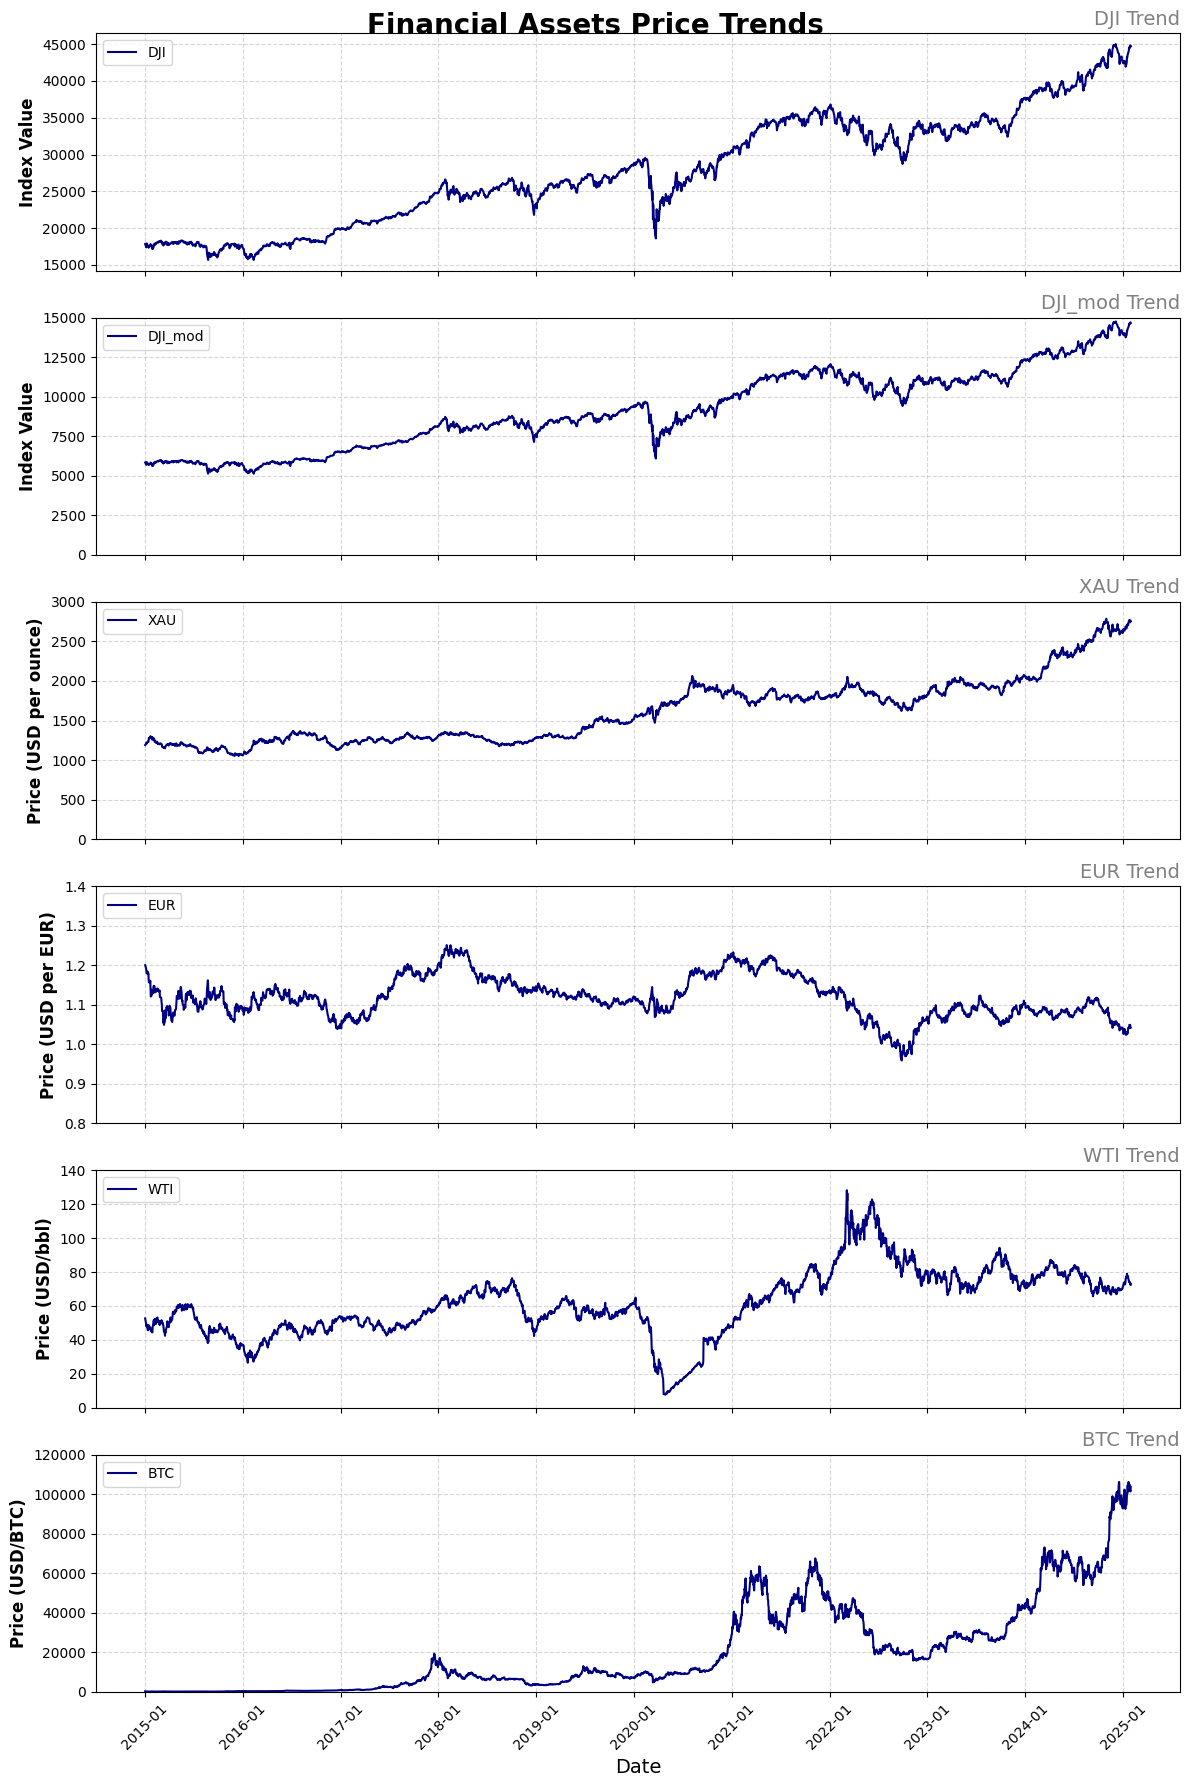

In [5]:
fig, axes = plt.subplots(nrows = 6, ncols = 1, figsize = (12, 20), sharex = True)

for i, (symbol, info) in enumerate(assets_info.items()):
    ax = axes[i]
    file_path = info['file']

    if not os.path.exists(file_path):
        print((f"File Error: {file_path} does not exists."))
        ax.text(0.5, 0.5, f"{symbol} data not found", ha = 'center', va = 'center')
        continue

    print(f"{symbol} - Loading data from {file_path}")

    df = pd.read_csv(file_path)

    df['Date'] = pd.to_datetime(df['Date'])

    price_col = 'Price' if 'Price' in df.columns else 'Close'

    if df[price_col].dtype == 'object':
        df[price_col] = df[price_col].str.replace(',', '').astype(float)

    df = df.sort_values('Date')

    if symbol == 'DJI_mod':
        df[price_col] = df[price_col] / 3.05

    ax.plot(df['Date'], df[price_col], label = symbol, color = info['color'], linewidth = 1.5)
    
    if 'ylim' in info:
        ymin, ymax = info['ylim']
        ax.set_ylim(ymin, ymax)

        if 'ystep' in info:
            step = info['ystep']
            ticks = np.arange(ymin, ymax + (step/1000), step)
            ax.set_yticks(ticks)

    ax.set_ylabel(info['label'], fontsize = 12, fontweight = 'bold')
    ax.legend(loc = 'upper left', fontsize = 10, frameon = True)
    ax.grid(True, linestyle = '--', alpha = 0.5)

    ax.set_title(f"{symbol} Trend", fontsize = 14, loc = 'right', color = 'gray')

plt.xlabel('Date', fontsize = 14)
plt.xticks(rotation = 45)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator())

plt.suptitle('Financial Assets Price Trends', fontsize = 20, fontweight = 'bold', y = 0.92)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
file_map = {
    # Semiconductor Stocks
    'NVDA': 'data/NVIDIA Stock Price History.csv',
    'AMD': 'data/AMD Stock Price History.csv',
    'AVGO': 'data/Broadcom Stock Price History.csv',
    'INTC': 'data/Intel Stock Price History.csv',
    # Financial Assets
    'DJI': 'data/Dow Jones Industrial Average Historical Data.csv',
    'XAU': 'data/XAU_USD Historical Data.csv',
    'EUR': 'data/EUR_USD Historical Data.csv',
    'WTI': 'data/WTI_USD Historical Data.csv',
    'BTC': 'data/Bitcoin Historical Data.csv',
}


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
Mean,0.22%,0.15%,0.12%,-0.02%,0.04%,0.03%,-0.01%,0.01%,0.23%
Std Dev,3.08%,3.63%,2.38%,2.28%,1.11%,0.89%,0.50%,2.89%,4.39%
Min,-20.79%,-27.75%,-22.19%,-30.19%,-13.84%,-5.90%,-2.40%,-41.77%,-49.73%
Max,26.37%,42.06%,21.86%,17.83%,10.76%,4.69%,3.04%,40.35%,24.08%


,NVDA,AMD,AVGO,INTC,DJI,XAU,EUR,WTI,BTC
NVDA,1.00,0.59,0.60,0.47,0.52,0.01,0.04,0.12,0.20
AMD,0.59,1.00,0.45,0.38,0.42,0.03,0.07,0.12,0.14
AVGO,0.60,0.45,1.00,0.50,0.58,0.03,0.05,0.18,0.15
INTC,0.47,0.38,0.50,1.00,0.58,0.04,0.02,0.16,0.16
DJI,0.52,0.42,0.58,0.58,1.00,0.01,0.08,0.28,0.21
XAU,0.01,0.03,0.03,0.04,0.01,1.00,0.37,0.08,0.09
EUR,0.04,0.07,0.05,0.02,0.08,0.37,1.00,0.04,0.06
WTI,0.12,0.12,0.18,0.16,0.28,0.08,0.04,1.00,0.05
BTC,0.20,0.14,0.15,0.16,0.21,0.09,0.06,0.05,1.00


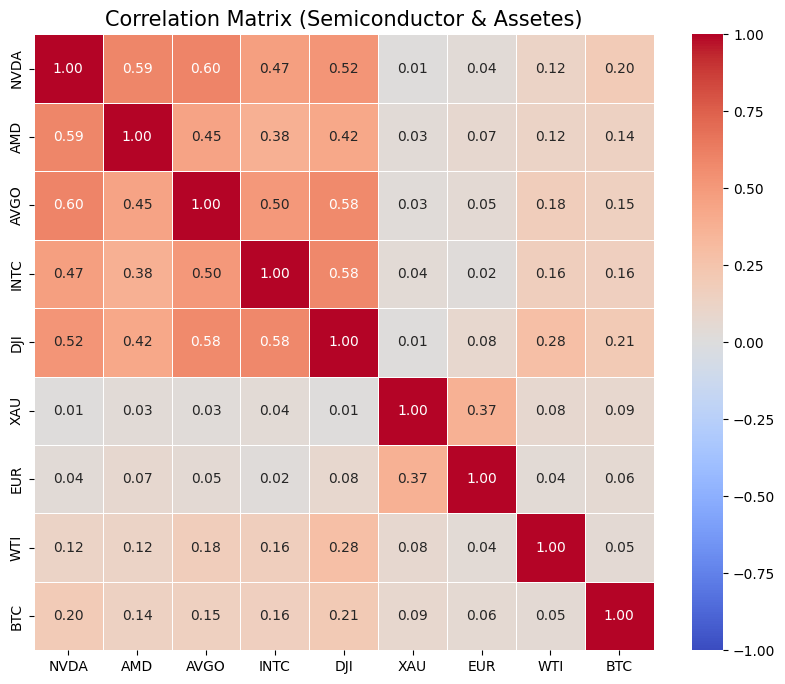

In [7]:
def load_data(file_map):
    df = pd.DataFrame()

    for symbol, file_path in file_map.items():
        if not os.path.exists(file_path):
            print(f"File Error: {file_path} does not exists.")
            continue

        temp_df = pd.read_csv(file_path)
        temp_df['Date'] = pd.to_datetime(temp_df['Date'])

        col_name = 'Price' if 'Price' in temp_df.columns else 'Close'
        if temp_df[col_name].dtype == 'object':
            temp_df[col_name] = temp_df[col_name].str.replace(',', '').astype(float)

        temp_df = temp_df.sort_values('Date').set_index('Date')
        temp_df = temp_df[[col_name]].rename(columns={col_name: symbol})

        if df.empty:
            df = temp_df
        else:
            df = df.join(temp_df, how = 'inner')
    return df

df_price = load_data(file_map)

log_returns_pct = np.log(df_price / df_price.shift(1)) * 100
log_returns_pct = log_returns_pct.dropna()

table1 = log_returns_pct.describe().T[['mean', 'std', 'min', 'max']]

table1.columns = ['Mean', 'Std Dev', 'Min', 'Max']

table1 = table1.T

display(table1.style.format("{:.2f}%"))
print("="*50)

table2 = log_returns_pct.corr(method = 'pearson')
display(table2.style.background_gradient(cmap = 'coolwarm', axis = None).format("{:.2f}"))

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(table2, dtype = bool))
sns.heatmap(table2, annot = True, fmt = ".2f", cmap = 'coolwarm', linewidth = 0.5, vmin = -1, vmax = 1, center = 0)
plt.title('Correlation Matrix (Semiconductor & Assetes)', fontsize = 15)
plt.show()

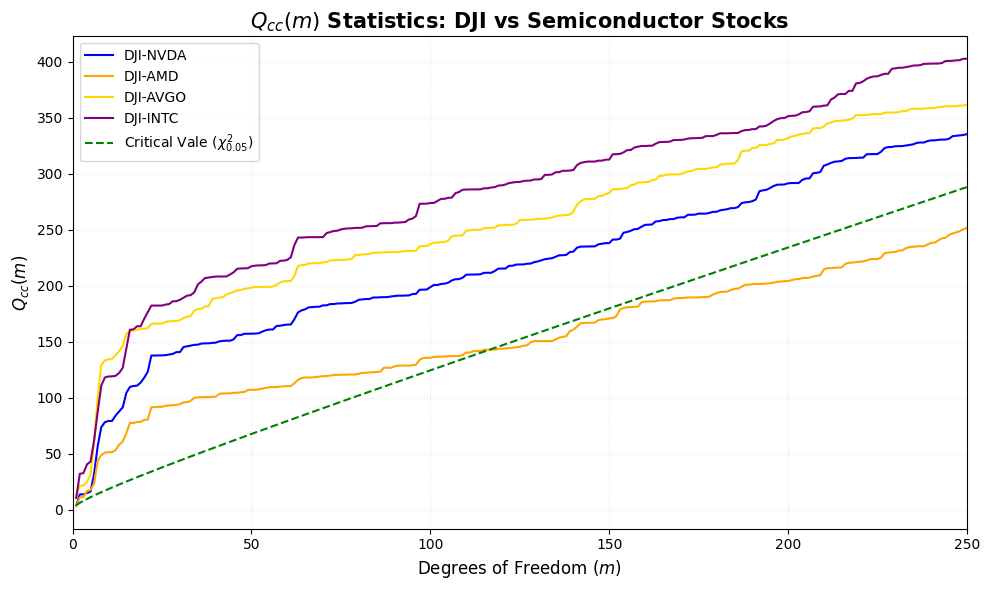

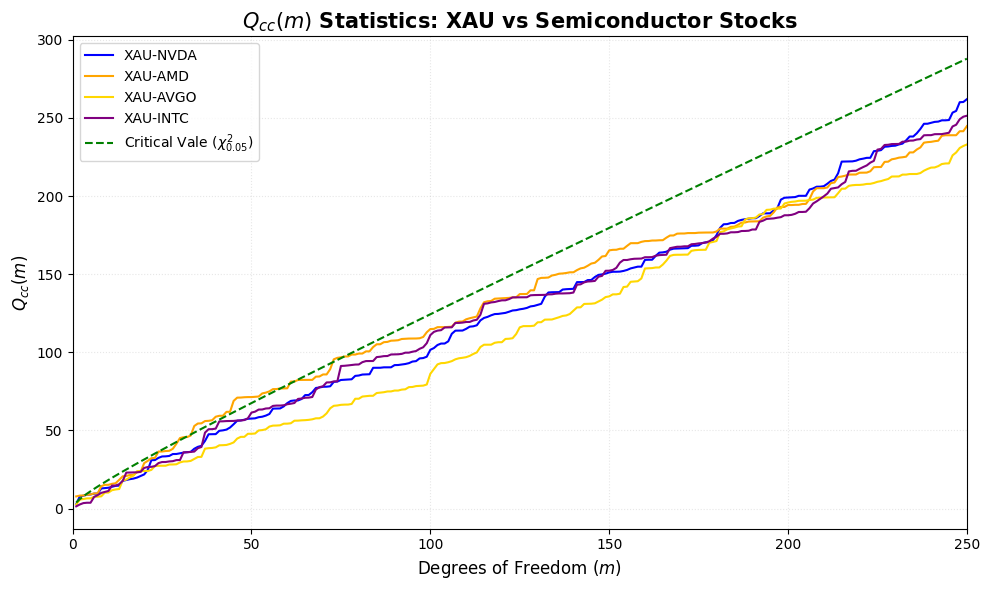

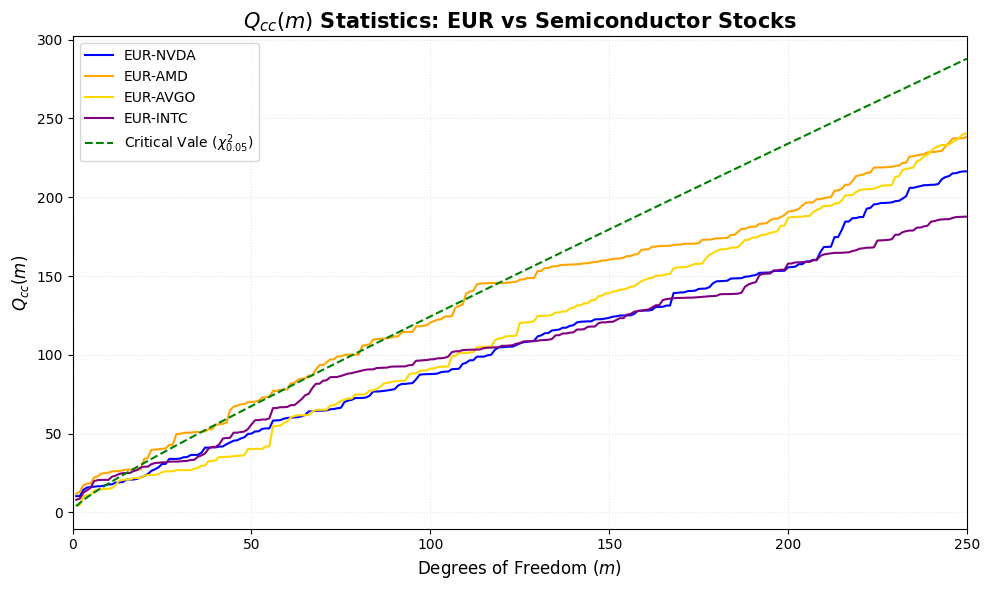

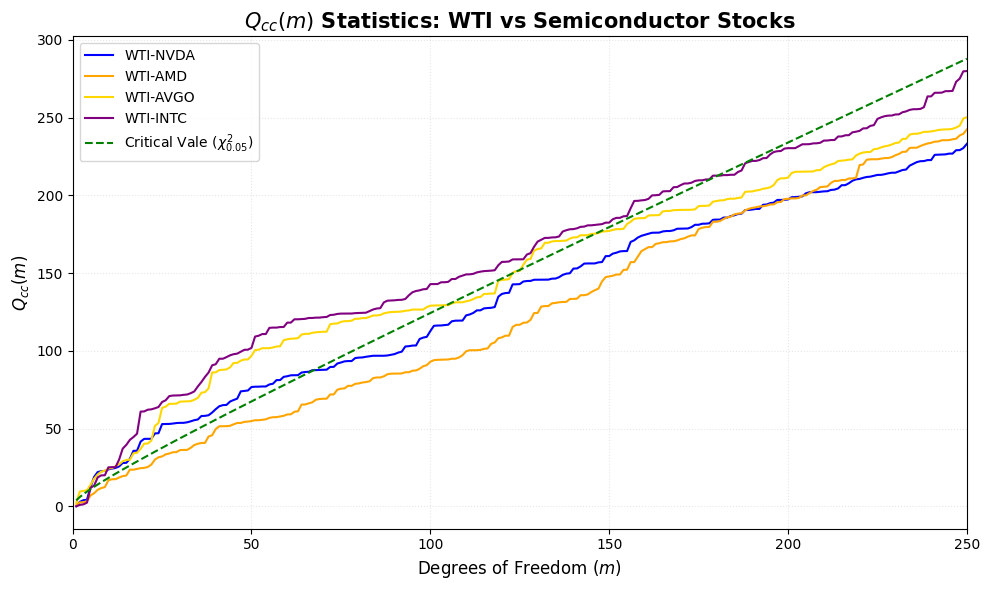

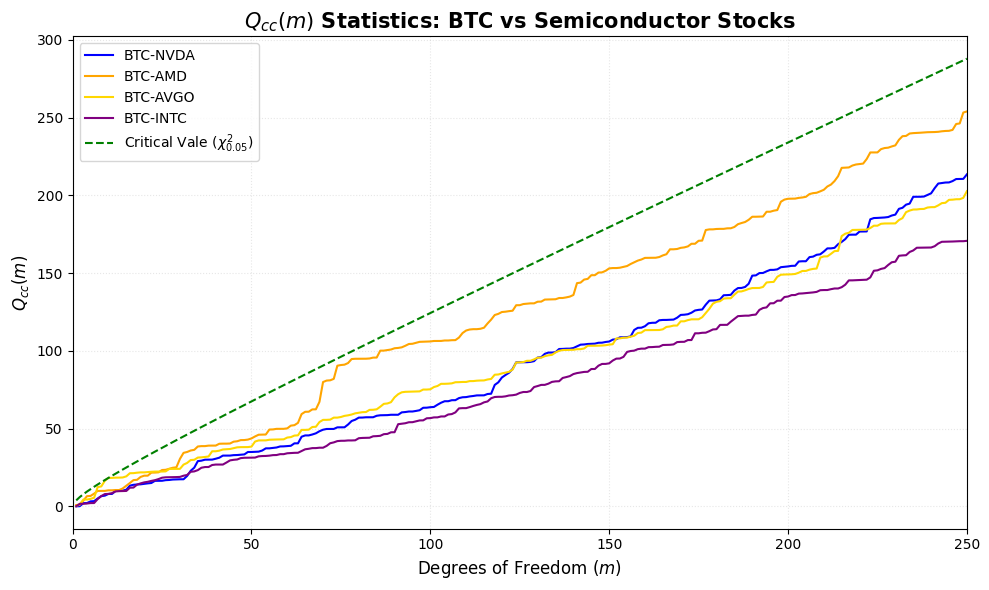

In [28]:
semi_stock = ['NVDA', 'AMD', 'AVGO', 'INTC']
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']

log_returns = np.log(df_price / df_price.shift(1)).dropna()

def calculate_qcc(series_x, series_y, max_m = 250):
    common_df = pd.concat([series_x, series_y], axis = 1).dropna()
    x = common_df.iloc[:, 0].values
    y = common_df.iloc[:, 1].values
    N = len(x)

    if N < max_m + 10: return None
    q_stat_list = []
    cumulative_sum = 0
    
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    x_std = np.std(x)
    y_std = np.std(y)
    
    denom = N * x_std * y_std

    for i in range(1, max_m + 1):
        x_lag = x[i:]
        y_lag = y[:-i]
        
        numerator = np.sum((x_lag - x_mean) * (y_lag - y_mean))
        
        rho_i = numerator / denom 
        
        cumulative_sum += (rho_i ** 2) / (N - i)
        
        q_stat = N * (N + 2) * cumulative_sum
        q_stat_list.append(q_stat)

    return q_stat_list

max_m_val = 250
m_range = range(1, max_m_val + 1)

critical_values = [stats.chi2.ppf(0.95, df = m) for m in m_range]

colors = {'NVDA': 'blue', 'AMD': 'orange', 'AVGO': 'gold', 'INTC': 'purple'}

for asset in financial_assets:
    if asset not in log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    asset_data = log_returns[asset]
    plot_exists = False

    for stock in semi_stock:
        if stock not in log_returns.columns: continue

        q_stats = calculate_qcc(asset_data, log_returns[stock], max_m = max_m_val)

        if q_stats is not None:
            plt.plot(m_range, q_stats, label = f'{asset}-{stock}', color = colors[stock], linewidth = 1.5)
            plot_exists = True
    
    if plot_exists:
        plt.plot(m_range, critical_values, label = 'Critical Vale ($\chi^2_{0.05}$)',
                 color = 'green', linestyle = '--', linewidth = 1.5)
        
        plt.title(f'$Q_{{cc}}(m)$ Statistics: {asset} vs Semiconductor Stocks', fontsize = 15, fontweight = 'bold')
        plt.xlabel('Degrees of Freedom ($m$)', fontsize = 12)
        plt.ylabel('$Q_{{cc}}(m)$', fontsize = 12)
        plt.legend(loc = 'upper left', fontsize = 10)
        plt.grid(True, linestyle = ':', alpha = 0.3)
        plt.xlim(0, max_m_val)

        plt.tight_layout()
        plt.show()


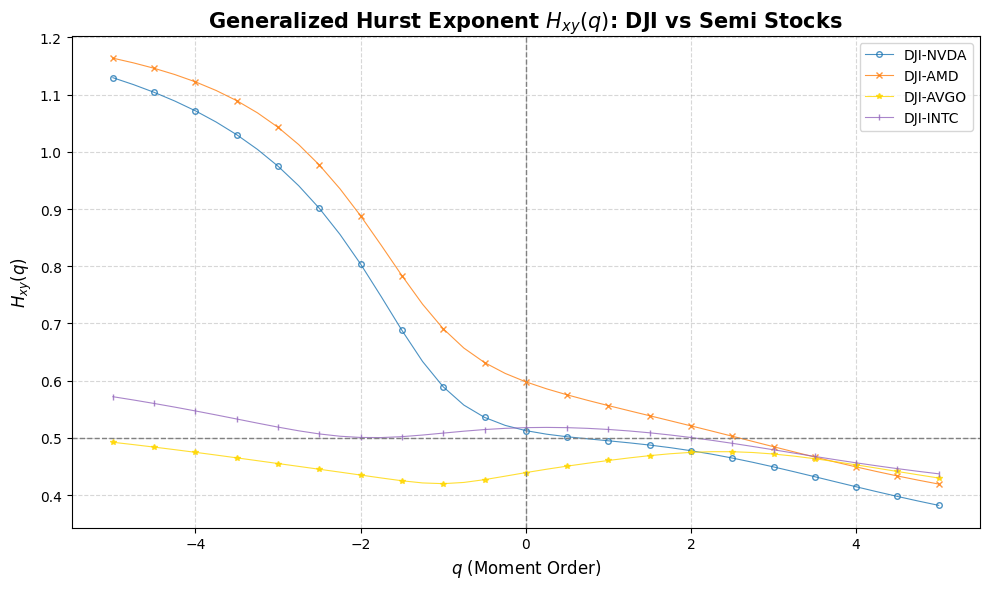

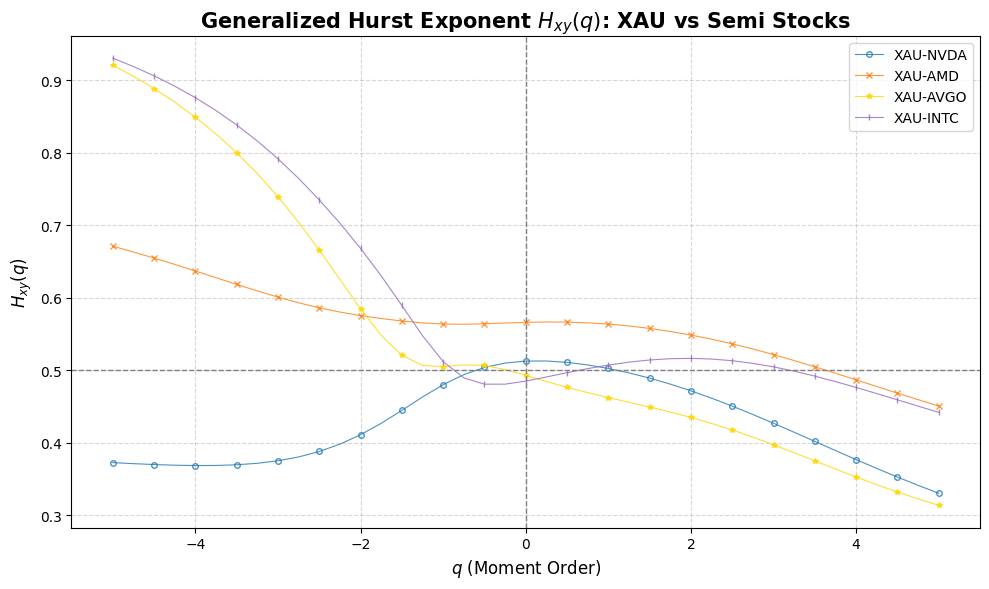

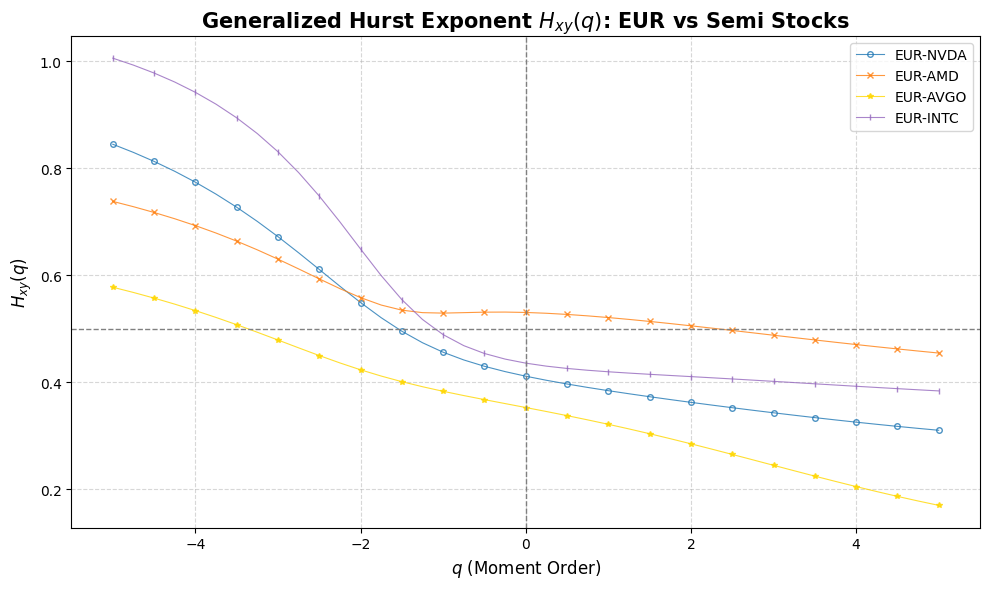

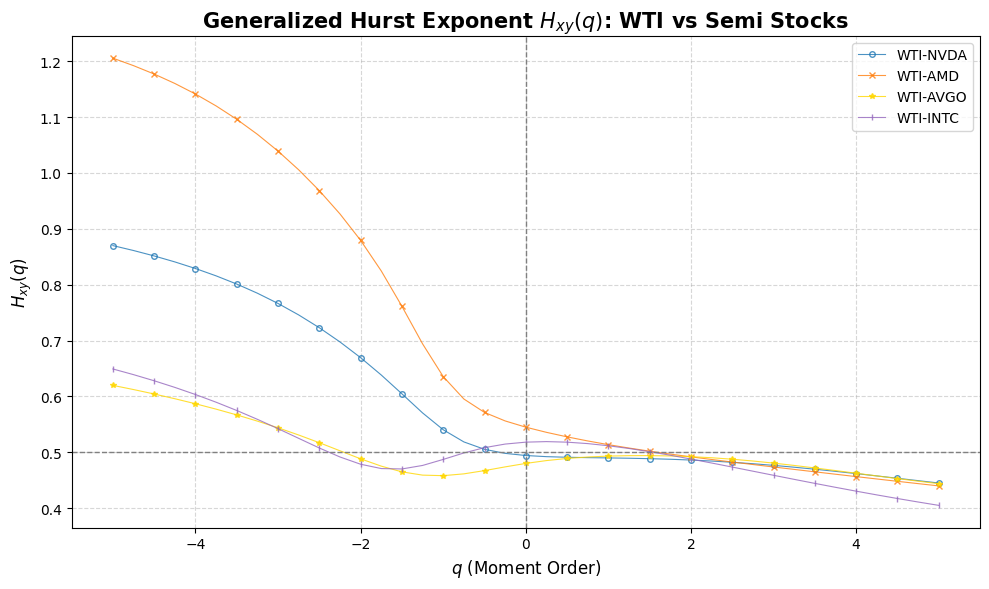

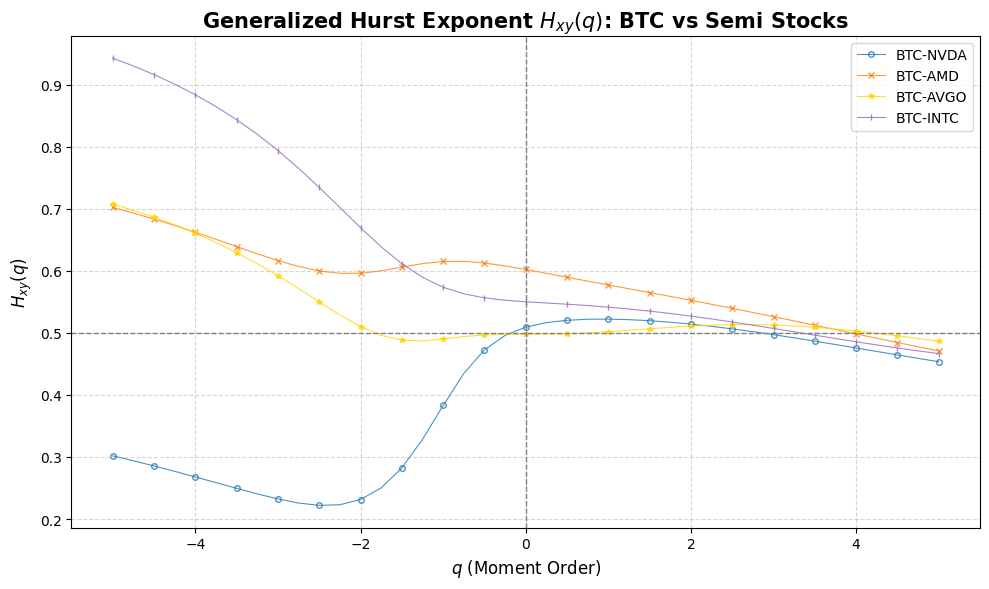

In [21]:

def calculate_hxy(series_x, series_y, q_range, scales, poly_order):
    X = series_x.values
    Y = series_y.values

    X_profile = np.cumsum(X - np.mean(X))
    Y_profile = np.cumsum(Y - np.mean(Y))

    N = len(X)
    F_q_s = np.zeros((len(q_range), len(scales)))


    for i_s, s in enumerate(scales):
        s = int(s)
        N_s = N // s

        f2_v = np.zeros(2 * N_s)
        x_axis = np.arange(s)

        for v in range(N_s):
            idx_start = v * s
            idx_end = idx_start + s
            x_seg = X_profile[idx_start:idx_end]
            y_seg = Y_profile[idx_start:idx_end]

            p_x = np.polyfit(x_axis, x_seg, poly_order)
            p_y = np.polyfit(x_axis, y_seg, poly_order)

            resid_x = x_seg - np.polyval(p_x, x_axis)
            resid_y = y_seg - np.polyval(p_y, x_axis)

            f2_v[v] = np.mean(resid_x * resid_y)

            idx_start_b = N - (v + 1) * s
            idx_end_b = N - v * s
            x_seg_b = X_profile[idx_start_b:idx_end_b]
            y_seg_b = Y_profile[idx_start_b:idx_end_b]

            p_x_b = np.polyfit(x_axis, x_seg_b, poly_order)
            p_y_b = np.polyfit(x_axis, y_seg_b, poly_order)

            resid_x_b = x_seg_b - np.polyval(p_x_b, x_axis)
            resid_y_b = y_seg_b - np.polyval(p_y_b, x_axis)

            f2_v[N_s + v] = np.mean(resid_x_b * resid_y_b)

        f2_abs = np.abs(f2_v)
        f2_abs[f2_abs < 1e-10] = 1e-10

        for i_q, q in enumerate(q_range):
            if abs(q) < 1e-5:
                F_val = np.exp(0.5 * np.mean(np.log(f2_abs)))
            else:
                mean_val = np.mean(f2_abs ** (q/2))
                F_val = mean_val ** (1 / q)
            F_q_s[i_q, i_s] = F_val

    h_xy_list = []
    log_s = np.log(scales)

    for i_q in range(len(q_range)):
        log_F = np.log(F_q_s[i_q, :])
        valid_mask = np.isfinite(log_F) & np.isfinite(log_s)
        if np.sum(valid_mask) >= 3:
            slope, _, _, _, _ = linregress(log_s[valid_mask], log_F[valid_mask])
            h_xy_list.append(slope)
        else:
            h_xy_list.append(np.nan)

    return np.array(h_xy_list)

styles = {
    'NVDA': {'marker': 'o', 'fillstyle': 'none', 'color': 'tab:blue', 'label': 'NVDA'}, 
    'AMD':  {'marker': 'x', 'fillstyle': 'full', 'color': 'tab:orange', 'label': 'AMD'}, 
    'AVGO': {'marker': '*', 'fillstyle': 'full', 'color': 'gold', 'label': 'AVGO'}, 
    'INTC': {'marker': '|', 'fillstyle': 'full', 'color': 'tab:purple', 'label': 'INTC'} 
}

q_range = np.linspace(-5, 5, 41)
min_scale = 25
max_scale = 150
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 15).astype(int))
poly_order = 3


for asset in financial_assets:
    if asset not in log_returns.columns: continue

    plt.figure(figsize = (10, 6))
    plot_exists = False

    for stock in semi_stock:
        if stock not in log_returns.columns: continue

        df_pair = log_returns[[asset, stock]].dropna()
        if len(df_pair) < 300:
            continue

        h_vals = calculate_hxy(df_pair[asset], df_pair[stock], q_range, scales, poly_order)

        if not np.all(np.isnan(h_vals)):
            st = styles[stock]
            plt.plot(q_range, h_vals, label = f'{asset}-{stock}', color = st['color'], linewidth = 0.8,
                     marker = st['marker'], markersize = 4, fillstyle = st['fillstyle'],
                     markevery = 2, alpha = 0.8)
            plot_exists = True
        
    if plot_exists:
        plt.title(f"Generalized Hurst Exponent $H_{{xy}}(q)$: {asset} vs Semi Stocks", fontsize = 15, fontweight = 'bold')
        plt.xlabel('$q$ (Moment Order)', fontsize=12)
        plt.ylabel('$H_{{xy}}(q)$', fontsize=12)
        plt.axhline(y=0.5, color='gray', linestyle='--', linewidth = 1)
        plt.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
        plt.legend(loc='best')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        plt.close()

🚀 모든 쌍(20개)에 대한 Scaling Law 검사를 시작합니다...
   (R^2 값이 0.9 미만인 경우 경고 메시지가 출력됩니다)

⚠️ [주의] DJI-NVDA (q=-5): R^2 = 0.6501 (선형성 약함)
⚠️ [주의] DJI-AMD (q=-5): R^2 = 0.8671 (선형성 약함)
⚠️ [주의] DJI-AVGO (q=-5): R^2 = 0.7950 (선형성 약함)
⚠️ [주의] DJI-AVGO (q=5): R^2 = 0.8603 (선형성 약함)
⚠️ [주의] DJI-INTC (q=-5): R^2 = 0.6099 (선형성 약함)
⚠️ [주의] DJI-INTC (q=5): R^2 = 0.8372 (선형성 약함)
⚠️ [주의] XAU-NVDA (q=-5): R^2 = 0.7694 (선형성 약함)
⚠️ [주의] XAU-AMD (q=-5): R^2 = 0.5670 (선형성 약함)
⚠️ [주의] XAU-AVGO (q=-5): R^2 = 0.5310 (선형성 약함)
⚠️ [주의] XAU-AVGO (q=5): R^2 = 0.7278 (선형성 약함)
⚠️ [주의] XAU-INTC (q=-5): R^2 = 0.6389 (선형성 약함)
⚠️ [주의] EUR-NVDA (q=-5): R^2 = 0.8913 (선형성 약함)
⚠️ [주의] EUR-AMD (q=-5): R^2 = 0.7346 (선형성 약함)
⚠️ [주의] EUR-AVGO (q=-5): R^2 = 0.4620 (선형성 약함)
⚠️ [주의] EUR-AVGO (q=0): R^2 = 0.8885 (선형성 약함)
⚠️ [주의] EUR-AVGO (q=5): R^2 = 0.8258 (선형성 약함)
⚠️ [주의] EUR-INTC (q=-5): R^2 = 0.7247 (선형성 약함)
⚠️ [주의] WTI-NVDA (q=-5): R^2 = 0.5262 (선형성 약함)
⚠️ [주의] WTI-AMD (q=-5): R^2 = 0.6001 (선형성 약함)
⚠️ [주의] WTI-AVGO (q=-5): R^2 = 0.3866

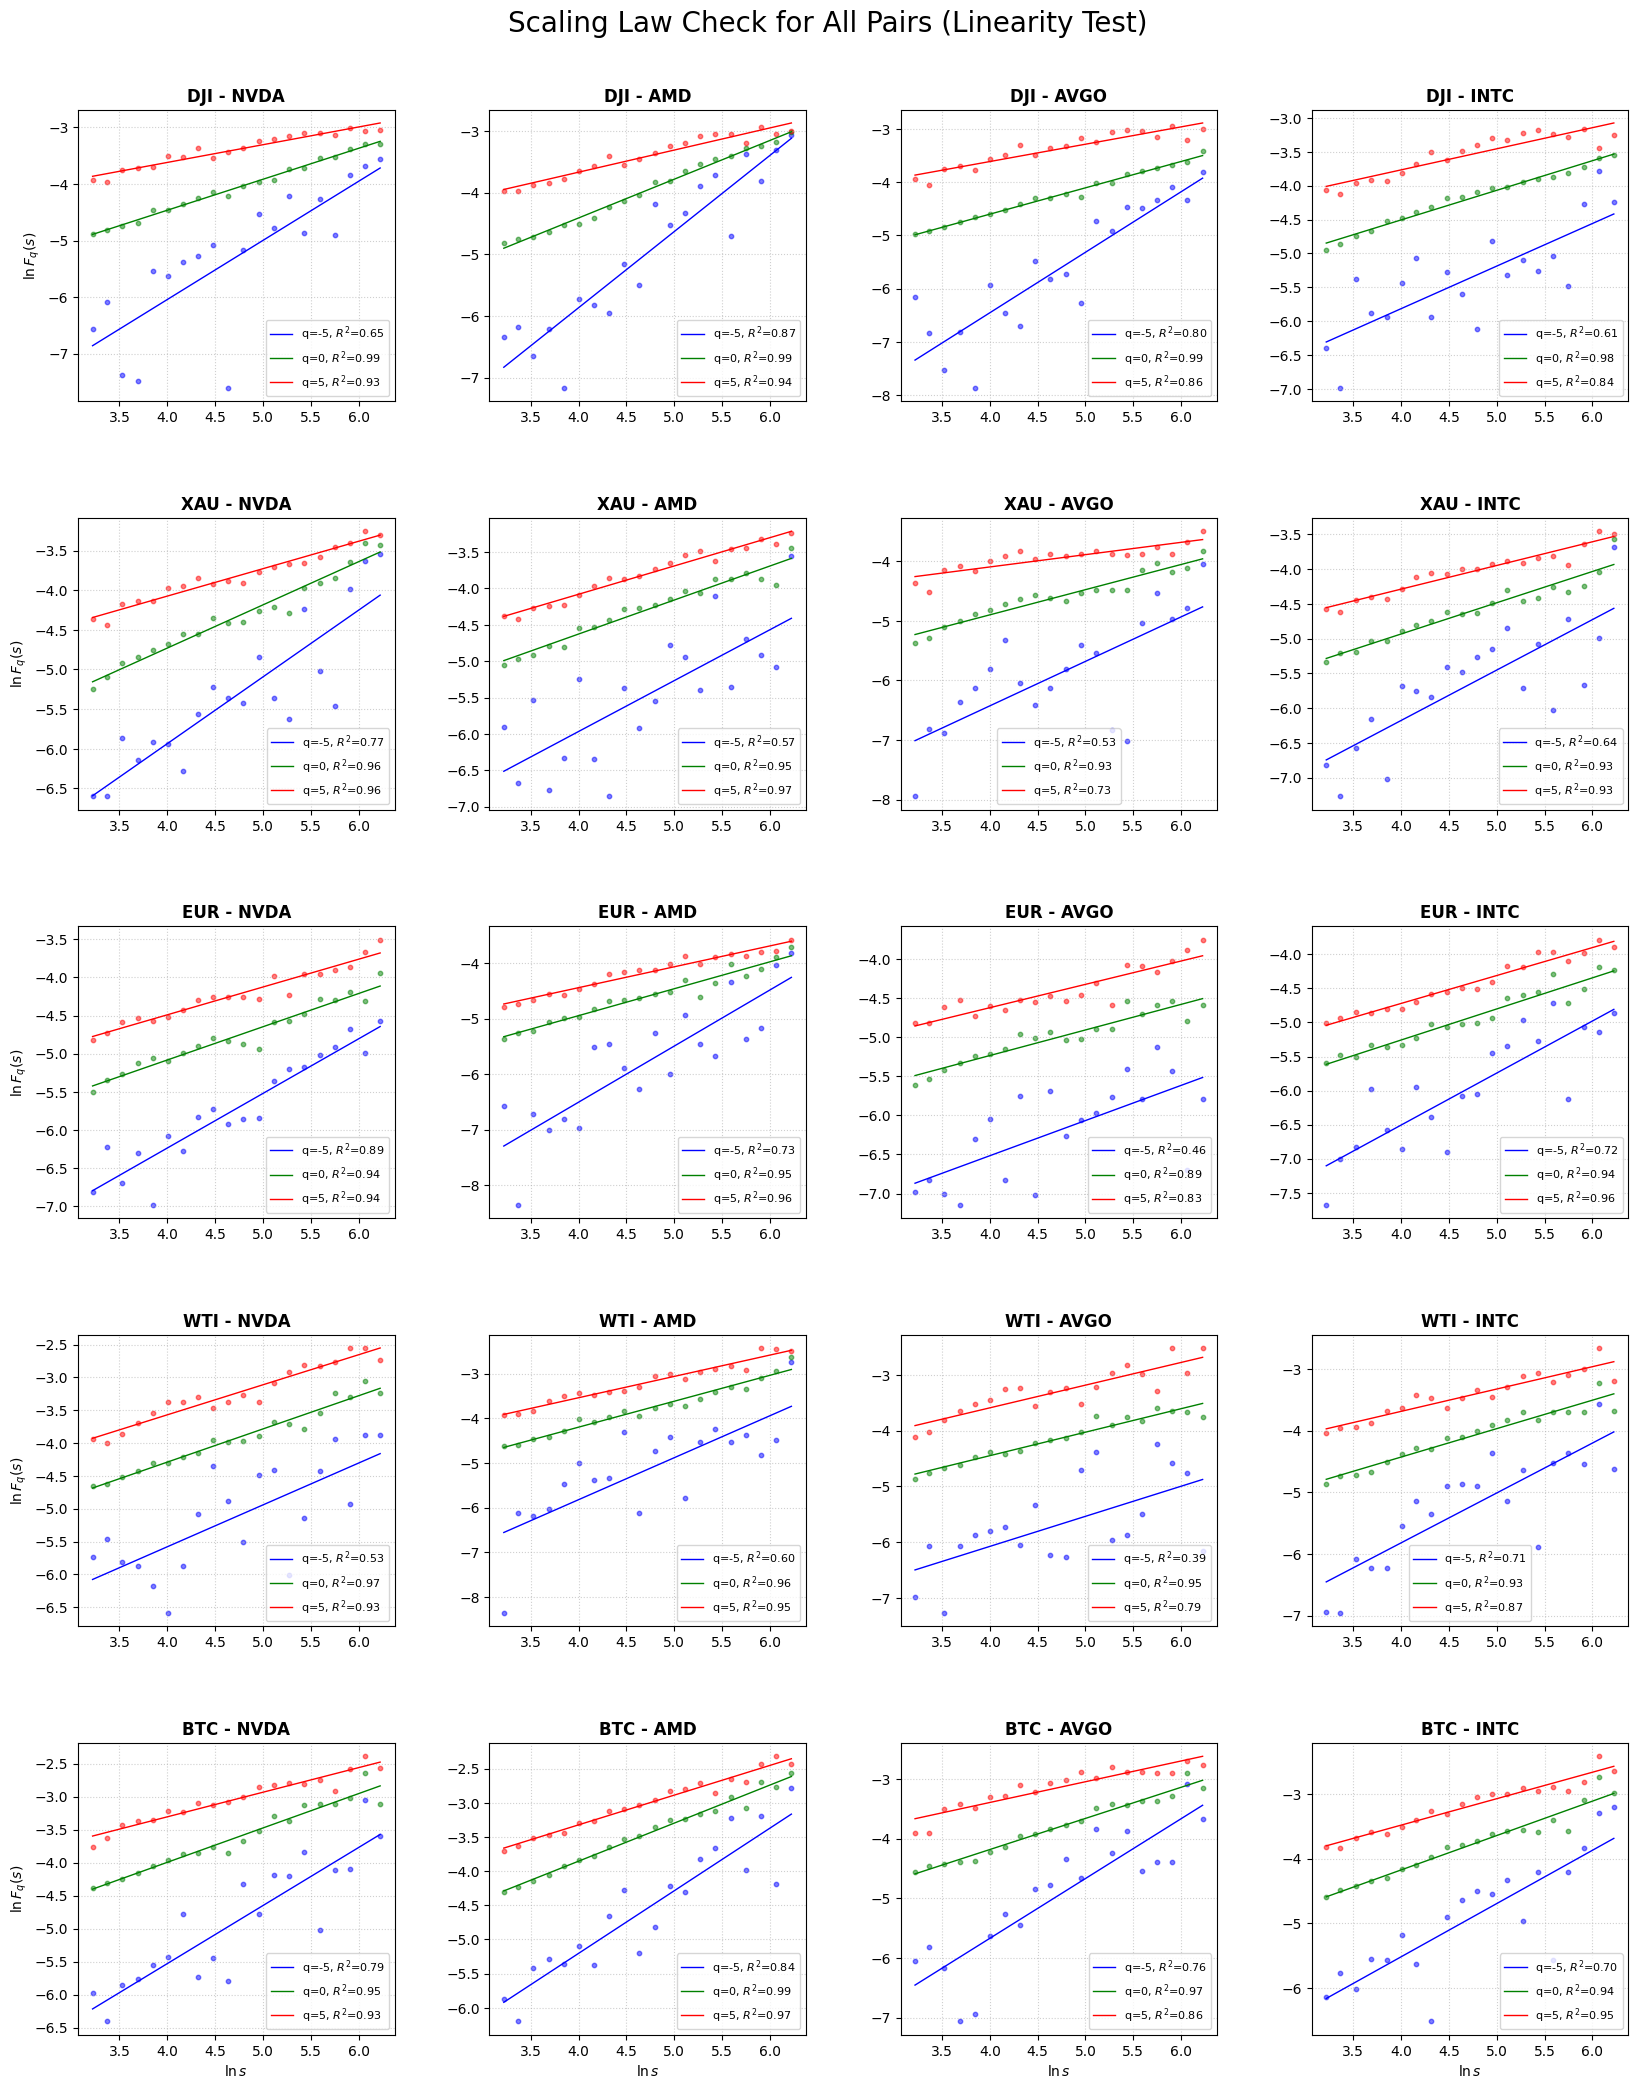

In [13]:
poly_order = 3
min_scale = 25
max_scale = len(log_returns) // 5
scales = np.unique(np.logspace(np.log10(min_scale), np.log10(max_scale), 20).astype(int))
q_check_list = [-5, 0, 5]  # 검사할 q값 (음수, 0, 양수)

# [2] Scaling Law 계산 함수 (재정의)
def check_scaling_law_final(series_x, series_y, scales, poly_order, q_list):
    X = series_x.values
    Y = series_y.values
    X_profile = np.cumsum(X - np.mean(X))
    Y_profile = np.cumsum(Y - np.mean(Y))
    N = len(X)
    
    results = {q: {'s': [], 'F': []} for q in q_list}
    
    for s in scales:
        s = int(s)
        if s < poly_order + 2: continue
        N_s = N // s
        f2_v = np.zeros(2 * N_s)
        x_axis = np.arange(s)
        
        for v in range(N_s):
            # Forward
            sl = slice(v*s, v*s+s)
            x_seg, y_seg = X_profile[sl], Y_profile[sl]
            p_x, p_y = np.polyfit(x_axis, x_seg, poly_order), np.polyfit(x_axis, y_seg, poly_order)
            f2_v[v] = np.mean((x_seg - np.polyval(p_x, x_axis)) * (y_seg - np.polyval(p_y, x_axis))) # 곱하기
            
            # Backward
            sl_b = slice(N-(v+1)*s, N-v*s)
            x_seg_b, y_seg_b = X_profile[sl_b], Y_profile[sl_b]
            p_x_b, p_y_b = np.polyfit(x_axis, x_seg_b, poly_order), np.polyfit(x_axis, y_seg_b, poly_order)
            f2_v[N_s + v] = np.mean((x_seg_b - np.polyval(p_x_b, x_axis)) * (y_seg_b - np.polyval(p_y_b, x_axis))) # 곱하기
            
        f2_abs = np.abs(f2_v)
        f2_abs[f2_abs < 1e-20] = 1e-20
        
        for q in q_list:
            if abs(q) < 1e-5:
                F_val = np.exp(0.5 * np.mean(np.log(f2_abs)))
            else:
                F_val = np.mean(f2_abs ** (q/2)) ** (1 / q)
            results[q]['s'].append(s)
            results[q]['F'].append(F_val)
            
    return results

# [3] 5x4 그리드 시각화 (전수 조사)
fig, axes = plt.subplots(len(financial_assets), len(semi_stock), figsize=(20, 25))
# 간격 조정
plt.subplots_adjust(hspace=0.4, wspace=0.3)

print("🚀 모든 쌍(20개)에 대한 Scaling Law 검사를 시작합니다...")
print(f"   (R^2 값이 0.9 미만인 경우 경고 메시지가 출력됩니다)\n")

for i, asset in enumerate(financial_assets):
    for j, stock in enumerate(semi_stock):
        ax = axes[i, j]
        
        if asset not in log_returns.columns or stock not in log_returns.columns:
            ax.text(0.5, 0.5, "Data Missing", ha='center')
            continue
            
        # 계산
        res = check_scaling_law_final(log_returns[asset], log_returns[stock], scales, poly_order, q_check_list)
        
        colors = ['blue', 'green', 'red'] # q=-5, 0, 5 색상
        
        # 각 q값에 대해 Plotting
        for k, q in enumerate(q_check_list):
            s_vals = np.array(res[q]['s'])
            F_vals = np.array(res[q]['F'])
            
            # Log-Log 변환
            log_s = np.log(s_vals)
            log_F = np.log(F_vals)
            valid = np.isfinite(log_F)
            
            if np.sum(valid) < 3: continue
            
            # 회귀분석 (R^2 확인용)
            slope, intercept, r_val, _, _ = linregress(log_s[valid], log_F[valid])
            r_squared = r_val**2
            
            # 불량 감지 (R^2 < 0.9)
            if r_squared < 0.9:
                print(f"⚠️ [주의] {asset}-{stock} (q={q}): R^2 = {r_squared:.4f} (선형성 약함)")

            # 그래프 그리기
            ax.scatter(log_s[valid], log_F[valid], color=colors[k], s=10, alpha=0.5)
            ax.plot(log_s[valid], slope*log_s[valid] + intercept, color=colors[k], linewidth=1,
                    label=f'q={q}, $R^2$={r_squared:.2f}')
        
        ax.set_title(f'{asset} - {stock}', fontsize=12, fontweight='bold')
        if i == len(financial_assets)-1: ax.set_xlabel('$\ln s$')
        if j == 0: ax.set_ylabel('$\ln F_q(s)$')
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(fontsize=8, loc='best')

plt.suptitle("Scaling Law Check for All Pairs (Linearity Test)", fontsize=20, y=0.92)
plt.show()

🔎 Scanning optimal min_scale from 15 to 100...

✅ 추천 최적 min_scale: 25 (Avg R^2: 0.8571)


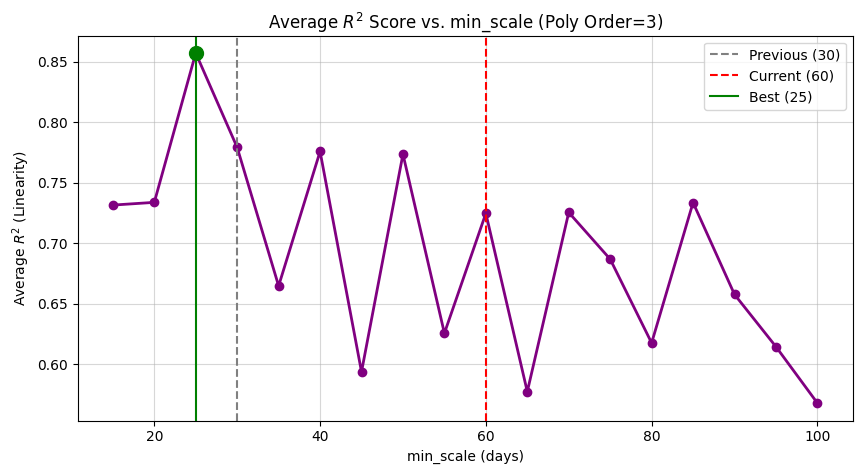

In [12]:
financial_assets = ['DJI', 'XAU', 'EUR', 'WTI', 'BTC']
semi_stocks = ['NVDA', 'AMD', 'AVGO', 'INTC']
poly_order = 3  # 논문 고정

# [2] R^2 스캔 함수
def scan_best_min_scale(min_scale_candidates, q_list=[-5, 5]):
    avg_r2_scores = []
    
    print(f"🔎 Scanning optimal min_scale from {min_scale_candidates[0]} to {min_scale_candidates[-1]}...")
    
    for ms in min_scale_candidates:
        ms = int(ms)
        # 스케일 설정 (min_scale 변화)
        max_s = len(log_returns) // 5
        scales = np.unique(np.logspace(np.log10(ms), np.log10(max_s), 15).astype(int))
        
        # 스케일 개수가 너무 적으면 패스 (통계적 의미 없음)
        if len(scales) < 5: 
            avg_r2_scores.append(np.nan)
            continue
            
        total_r2 = 0
        count = 0
        
        # 대표적인 몇 개 쌍만 샘플링해서 검사 (시간 절약)
        # (BTC-NVDA, DJI-INTC 정도만 봐도 경향성 파악 가능)
        sample_pairs = [('BTC', 'NVDA'), ('DJI', 'INTC')]
        
        for asset, stock in sample_pairs:
            if asset not in log_returns.columns or stock not in log_returns.columns: continue
            
            # --- Hxy 로직 (축약본) ---
            # (속도를 위해 함수 호출 대신 내부에 구현)
            X = log_returns[asset].values
            Y = log_returns[stock].values
            X_profile = np.cumsum(X - np.mean(X))
            Y_profile = np.cumsum(Y - np.mean(Y))
            N = len(X)
            
            # 특정 q값들에 대해서만 R^2 계산
            for q in q_list:
                s_vals = []
                F_vals = []
                
                for s in scales:
                    s = int(s)
                    N_s = N // s
                    f2_v = np.zeros(2 * N_s)
                    x_axis = np.arange(s)
                    
                    for v in range(N_s):
                        sl = slice(v*s, v*s+s)
                        # Forward
                        p_x = np.polyfit(x_axis, X_profile[sl], poly_order)
                        p_y = np.polyfit(x_axis, Y_profile[sl], poly_order)
                        res_x = X_profile[sl] - np.polyval(p_x, x_axis)
                        res_y = Y_profile[sl] - np.polyval(p_y, x_axis)
                        f2_v[v] = np.mean(res_x * res_y)
                        
                        # Backward
                        sl_b = slice(N-(v+1)*s, N-v*s)
                        p_x_b = np.polyfit(x_axis, X_profile[sl_b], poly_order)
                        p_y_b = np.polyfit(x_axis, Y_profile[sl_b], poly_order)
                        res_x_b = X_profile[sl_b] - np.polyval(p_x_b, x_axis)
                        res_y_b = Y_profile[sl_b] - np.polyval(p_y_b, x_axis)
                        f2_v[N_s + v] = np.mean(res_x_b * res_y_b)

                    f2_abs = np.abs(f2_v)
                    f2_abs[f2_abs < 1e-20] = 1e-20
                    
                    if abs(q) < 1e-5: F_val = np.exp(0.5 * np.mean(np.log(f2_abs)))
                    else: F_val = np.mean(f2_abs ** (q/2)) ** (1 / q)
                    
                    s_vals.append(s)
                    F_vals.append(F_val)
                
                # R^2 계산
                log_s = np.log(s_vals)
                log_F = np.log(F_vals)
                valid = np.isfinite(log_F)
                if np.sum(valid) >= 3:
                    _, _, r_val, _, _ = linregress(log_s[valid], log_F[valid])
                    total_r2 += r_val**2
                    count += 1
        
        if count > 0:
            avg_r2_scores.append(total_r2 / count)
        else:
            avg_r2_scores.append(np.nan)
            
    return avg_r2_scores

# [3] 실행 및 시각화
# 15부터 100까지 5단위로 검사
candidates = np.arange(15, 105, 5)
r2_results = scan_best_min_scale(candidates)

plt.figure(figsize=(10, 5))
plt.plot(candidates, r2_results, marker='o', linestyle='-', color='purple', linewidth=2)
plt.axvline(x=30, color='gray', linestyle='--', label='Previous (30)')
plt.axvline(x=60, color='red', linestyle='--', label='Current (60)')

# 최고점 찾기
if not np.all(np.isnan(r2_results)):
    best_idx = np.nanargmax(r2_results)
    best_scale = candidates[best_idx]
    plt.axvline(x=best_scale, color='green', linestyle='-', label=f'Best ({best_scale})')
    plt.scatter(best_scale, r2_results[best_idx], s=100, c='green', zorder=5)
    print(f"\n✅ 추천 최적 min_scale: {best_scale} (Avg R^2: {r2_results[best_idx]:.4f})")
else:
    print("\n❌ 유효한 R^2를 계산하지 못했습니다.")

plt.title(f"Average $R^2$ Score vs. min_scale (Poly Order={poly_order})")
plt.xlabel("min_scale (days)")
plt.ylabel("Average $R^2$ (Linearity)")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()